# CARRY on ETH 2026-09 (AUDIT of the shipped rule on a second asset)

Pre-registration: [README.md](README.md) (frozen before any run). Write-up: [findings.md](findings.md).
The shipped CUM-30D carry rule on Binance ETHUSDT settlement prints, net of 0.24 % per toggle, with the C2 rule
simulator imported unchanged; the combined BTC + ETH book against BTC alone. Re-run: `run_eth.py`.


## Gates — C0 (prints = prod.db settlement rows) and parity with the BTC study

In [1]:
import json, pandas as pd
from pathlib import Path
R = Path('results')
J = json.loads((R / 'carry_eth.json').read_text(encoding='utf-8'))
print('generated by:', J['env'])
print('C0 gate:', J['c0_gate'])
print('parity vs the BTC study:', J['parity'])


generated by: {'python': '3.13.11', 'numpy': '2.2.6', 'pandas': '3.0.0', 'run_at': '2026-09-18T22:04:46+00:00'}
C0 gate: {'table': 'cd_funding_rate_eth', 'table_rows': 7359, 'fetched_prints': 7463, 'common': 7359, 'only_in_table': 0, 'only_fetched': 104, 'max_abs_diff': 0.0, 'pass_': True}
parity vs the BTC study: {'got': {'CUM30D': {'net_ann_pct': 11.567993012031904, 'rt_per_year': 0.7401649317290794}, 'ALWAYS_ON': {'net_ann_pct': 11.678817907259699}, 'LIVE': {'net_ann_pct': 10.833638078950928, 'rt_per_year': 4.737055563066108}}, 'expected': {'CUM30D': {'net_ann_pct': 11.58, 'rt_per_year': 0.74}, 'ALWAYS_ON': {'net_ann_pct': 11.69}, 'LIVE': {'net_ann_pct': 10.85, 'rt_per_year': 4.75}}, 'pass_': True}


## Rules on ETH and on BTC (the references are the BTC study's anchors)

In [2]:
for name in ('eth', 'btc'):
    r = J[name]
    print(f"{name.upper()} — {r['eval_span'][0]} .. {r['eval_span'][1]} ({r['years']:.2f} y, {r['n_prints']} prints)")
    display(pd.DataFrame(r['rules']).T.round(3))


ETH — 2020-03-06 .. 2026-09-18 (6.54 y, 7463 prints)


,share_held,round_trips,rt_per_year,gross_ann_pct,net_ann_pct
CUM30D,0.990,9.0,1.376,13.110,12.835
ALWAYS_ON,1.000,1.0,0.153,12.931,12.901
LIVE,0.913,25.0,3.822,13.264,12.500


BTC — 2019-12-19 .. 2026-09-18 (6.76 y, 7697 prints)


,share_held,round_trips,rt_per_year,gross_ann_pct,net_ann_pct
CUM30D,0.996,5.0,0.740,11.716,11.568
ALWAYS_ON,1.000,1.0,0.148,11.708,11.679
LIVE,0.906,32.0,4.737,11.781,10.834


## Per year, era, tail stress, bootstrap

In [3]:
pdf = pd.read_csv(R / 'per_year.csv')
for sym in ('ETHUSDT', 'BTCUSDT'):
    print(sym, 'net %/yr by year')
    display(pdf[pdf.symbol == sym].pivot_table(index='rule', columns='year', values='net_ann_pct').round(2))
print('ETH era split:', json.dumps(J['eth']['era'], indent=1))
print('ETH tail stress:', json.dumps(J['eth']['tail_stress'], indent=1))
print('ETH CUM30D bootstrap vs zero:', J['eth']['bootstrap_cum30d_vs_zero'])


ETHUSDT net %/yr by year


year,2020,2021,2022,2023,2024,2025,2026
rule,,,,,,,
ALWAYS_ON,22.77,37.54,0.79,8.26,12.96,4.93,1.58
CUM30D,22.77,37.54,0.36,8.26,12.96,4.93,1.58
LIVE,22.77,37.32,0.81,7.66,12.57,4.10,0.73


BTCUSDT net %/yr by year


year,2020,2021,2022,2023,2024,2025,2026
rule,,,,,,,
ALWAYS_ON,17.19,30.61,4.16,7.87,11.92,5.13,2.72
CUM30D,16.45,30.61,4.16,7.87,11.92,5.13,2.72
LIVE,16.32,30.08,2.49,7.24,11.53,4.51,1.70


ETH era split: {
 "CUM30D": {
  "pre_etf": {
   "net_ann_pct": 16.995215082997394,
   "round_trips": 9
  },
  "post_etf": {
   "net_ann_pct": 6.879456440936865,
   "round_trips": 0
  }
 },
 "ALWAYS_ON": {
  "pre_etf": {
   "net_ann_pct": 17.107408829736784,
   "round_trips": 1
  },
  "post_etf": {
   "net_ann_pct": 6.879456440936865,
   "round_trips": 0
  }
 },
 "LIVE": {
  "pre_etf": {
   "net_ann_pct": 16.900044081100308,
   "round_trips": 14
  },
  "post_etf": {
   "net_ann_pct": 6.201702734215888,
   "round_trips": 11
  }
 }
}
ETH tail stress: {
 "worst_30d": {
  "cum_funding_pct": -1.777489,
  "window": [
   "2022-08-27",
   "2022-09-25"
  ],
  "net_pct_in_window": {
   "CUM30D": -0.6684680000000001,
   "ALWAYS_ON": -1.777489,
   "LIVE": 0.0
  }
 },
 "worst_90d": {
  "cum_funding_pct": -1.668843,
  "window": [
   "2022-08-27",
   "2022-11-24"
  ],
  "net_pct_in_window": {
   "CUM30D": -2.100917,
   "ALWAYS_ON": -1.668843,
   "LIVE": -0.044618000000000047
  }
 },
 "worst_180d": {
 

## The combined book — the breadth test

combined book: {
 "common_span": [
  "2020-03-06",
  "2026-09-18"
 ],
 "btc_alone": {
  "days": 2388,
  "net_ann_pct": 10.939385557788942,
  "max_dd_pct": -2.2420430000000002,
  "net_over_dd": 4.879204171279918
 },
 "eth_alone": {
  "days": 2388,
  "net_ann_pct": 12.841802113065325,
  "max_dd_pct": -2.144139000000038,
  "net_over_dd": 5.989258211834725
 },
 "equal_weight": {
  "days": 2388,
  "net_ann_pct": 11.890593835427135,
  "max_dd_pct": -0.7861130000000001,
  "net_over_dd": 15.125807403550295
 },
 "corr_daily_funding": 0.8667571653798872,
 "corr_daily_net_cum30d": 0.8706581841676867
}


Text(0, 0.5, '%')

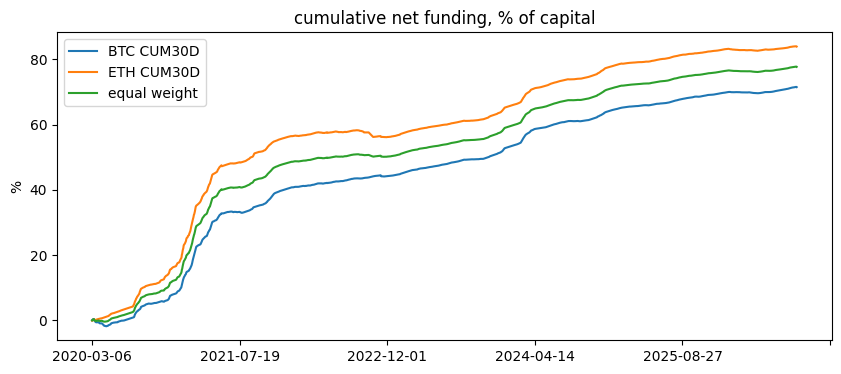

In [4]:
print('combined book:', json.dumps(J['combined'], indent=1))
cd = pd.read_csv(R / 'combined_daily.csv', index_col=0)
cum = (cd.cumsum() * 100).rename(columns={'btc_net': 'BTC CUM30D', 'eth_net': 'ETH CUM30D'})
cum['equal weight'] = (0.5 * cd.btc_net + 0.5 * cd.eth_net).cumsum() * 100
ax = cum.plot(figsize=(10, 4), title='cumulative net funding, % of capital')
ax.set_ylabel('%')


## Decision (rule fixed in README.md before the run)

In [5]:
print('DECISION:', json.dumps(J['decision'], indent=1))


DECISION: {
 "a_net_and_ci": true,
 "a_net_ann_pct": 12.834803948066451,
 "a_bar": 5.0,
 "a_ci90_low": 9.482122017939412,
 "b_worst_year_ok": true,
 "b_worst_year": 0.3551819999999997,
 "b_bar": -2.0,
 "c_equal_weight_not_worse": true,
 "c_equal_weight_net_over_dd": 15.125807403550295,
 "c_btc_alone_net_over_dd": 4.879204171279918,
 "verdict": "RECOMMEND an ETH paper twin"
}
